# Visualización de orientación — Silueta de dron

Carga un fichero de sensores, aplica el filtro de Madgwick (solo IMU, **sin magnetómetro**) y muestra una silueta de dron que se inclina según la orientación estimada.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
from ahrs.filters import Madgwick
import ipywidgets as widgets
from IPython.display import display

## 1. Carga de datos

In [3]:
DATA_FILE = '../data/Experiment_1_2026-03-04T200844.csv'

df = pd.read_csv(DATA_FILE)
df['t'] = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0

t = df['t'].values
dt = np.diff(t, prepend=t[0])
dt[0] = dt[1]
fs = 1.0 / np.mean(dt)

acc = np.column_stack([df['accel_x'], df['accel_y'], df['accel_z']])
gyr = np.column_stack([df['gyro_x'], df['gyro_y'], df['gyro_z']])

print(f'Muestras: {len(df)}  |  Duración: {t[-1]:.1f} s  |  Fs: {fs:.0f} Hz')

Muestras: 1691  |  Duración: 17.1 s  |  Fs: 99 Hz


## 2. Filtro de Madgwick (solo IMU, sin magnetómetro)

In [4]:
madgwick = Madgwick(gyr=gyr, acc=acc, frequency=fs, gain=0.041)
Q = madgwick.Q  # (N, 4) — [w, x, y, z]

print(f'Cuaterniones: {Q.shape}')
print(f'q[0] = [{Q[0,0]:.4f}, {Q[0,1]:.4f}, {Q[0,2]:.4f}, {Q[0,3]:.4f}]')

Cuaterniones: (1691, 4)
q[0] = [0.9999, -0.0060, -0.0094, -0.0001]


## 3. Funciones auxiliares

In [5]:
def quat_to_rotation_matrix(q):
    """Cuaternión [w,x,y,z] → matriz de rotación 3x3."""
    w, x, y, z = q
    return np.array([
        [1 - 2*(y**2 + z**2),  2*(x*y - w*z),      2*(x*z + w*y)],
        [2*(x*y + w*z),        1 - 2*(x**2 + z**2), 2*(y*z - w*x)],
        [2*(x*z - w*y),        2*(y*z + w*x),       1 - 2*(x**2 + y**2)]
    ])


def quat_to_euler(q):
    """Cuaternión [w,x,y,z] → (roll, pitch, yaw) en grados."""
    w, x, y, z = q
    roll = np.degrees(np.arctan2(2*(w*x + y*z), 1 - 2*(x**2 + y**2)))
    sinp = np.clip(2*(w*y - z*x), -1.0, 1.0)
    pitch = np.degrees(np.arcsin(sinp))
    yaw = np.degrees(np.arctan2(2*(w*z + x*y), 1 - 2*(y**2 + z**2)))
    return roll, pitch, yaw


def make_drone_body():
    """
    Genera los puntos 3D de una silueta de dron (quadcopter):
    - 4 brazos desde el centro
    - Círculos (hélices) en las puntas
    - Flecha indicando el frente
    Todos los puntos en body frame, centrados en el origen.
    """
    arm_len = 0.4
    rotor_r = 0.12
    n_circle = 24

    # Posiciones de los 4 motores (en X-config)
    angles_arm = [45, 135, 225, 315]  # grados
    motor_pos = []
    for a in angles_arm:
        rad = np.radians(a)
        motor_pos.append([arm_len * np.cos(rad), arm_len * np.sin(rad), 0.0])

    parts = []

    # Brazos: líneas desde centro a cada motor
    for mp in motor_pos:
        parts.append({
            'points': np.array([[0, 0, 0], mp]),
            'color': '#555555',
            'lw': 3
        })

    # Hélices: círculos en cada motor
    theta_c = np.linspace(0, 2*np.pi, n_circle)
    for i, mp in enumerate(motor_pos):
        cx = mp[0] + rotor_r * np.cos(theta_c)
        cy = mp[1] + rotor_r * np.sin(theta_c)
        cz = np.full_like(cx, mp[2])
        circle = np.column_stack([cx, cy, cz])
        # Rotores delanteros rojos, traseros grises
        color = '#e74c3c' if i < 2 else '#888888'
        parts.append({
            'points': circle,
            'color': color,
            'lw': 2
        })

    # Flecha frontal (indica dirección +X del body)
    arrow_pts = np.array([
        [0.0, 0.0, 0.0],
        [0.18, 0.0, 0.0],
        [0.14, 0.04, 0.0],
        [0.18, 0.0, 0.0],
        [0.14, -0.04, 0.0],
    ])
    parts.append({
        'points': arrow_pts,
        'color': '#e74c3c',
        'lw': 2.5
    })

    # Cuerpo central (cuadrado pequeño)
    s = 0.08
    body_pts = np.array([
        [-s, -s, 0], [s, -s, 0], [s, s, 0], [-s, s, 0], [-s, -s, 0]
    ])
    parts.append({
        'points': body_pts,
        'color': '#2c3e50',
        'lw': 2
    })

    return parts


DRONE_PARTS = make_drone_body()

## 4. Visualización estática — Dron en un instante dado

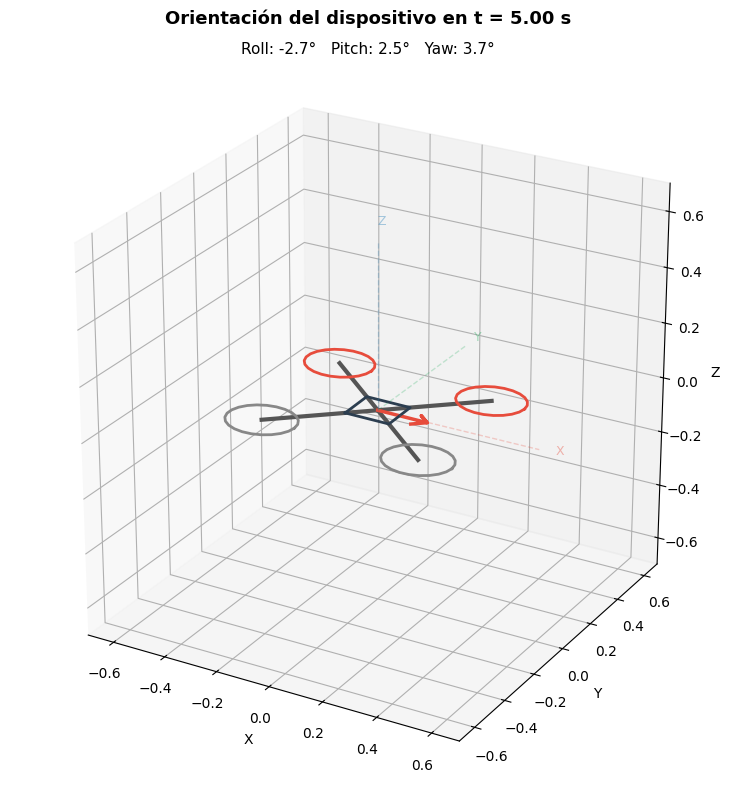

In [6]:
def draw_drone(ax, q, drone_parts, label_angles=True):
    """Dibuja la silueta del dron rotada según el cuaternión q."""
    R = quat_to_rotation_matrix(q)

    for part in drone_parts:
        pts = part['points']
        rotated = (R @ pts.T).T
        ax.plot(rotated[:, 0], rotated[:, 1], rotated[:, 2],
                color=part['color'], linewidth=part['lw'])

    # Ejes del world frame (referencia tenue)
    ax_len = 0.6
    for vec, c, lbl in [([1,0,0], '#e74c3c', 'X'),
                         ([0,1,0], '#27ae60', 'Y'),
                         ([0,0,1], '#2980b9', 'Z')]:
        v = np.array(vec) * ax_len
        ax.plot([0, v[0]], [0, v[1]], [0, v[2]],
               color=c, alpha=0.25, linewidth=1, linestyle='--')
        ax.text(v[0]*1.1, v[1]*1.1, v[2]*1.1, lbl,
               color=c, alpha=0.4, fontsize=9)

    # Etiqueta con ángulos
    if label_angles:
        roll, pitch, yaw = quat_to_euler(q)
        ax.set_title(f'Roll: {roll:.1f}°   Pitch: {pitch:.1f}°   Yaw: {yaw:.1f}°',
                    fontsize=11)

    ax.set_xlim([-0.7, 0.7])
    ax.set_ylim([-0.7, 0.7])
    ax.set_zlim([-0.7, 0.7])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_aspect('equal')


# Ejemplo: dibujar en el instante t=5s
sample_idx = np.argmin(np.abs(t - 5.0))

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')
draw_drone(ax, Q[sample_idx], DRONE_PARTS)
ax.view_init(elev=25, azim=-60)
plt.suptitle(f'Orientación del dispositivo en t = {t[sample_idx]:.2f} s',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Explorador interactivo con slider

In [7]:
def plot_at_sample(sample):
    fig = plt.figure(figsize=(12, 5))

    # --- Panel izquierdo: dron 3D ---
    ax3d = fig.add_subplot(121, projection='3d')
    draw_drone(ax3d, Q[sample], DRONE_PARTS)
    ax3d.view_init(elev=25, azim=-60)

    # --- Panel derecho: ángulos en el tiempo ---
    ax2d = fig.add_subplot(122)

    # Calcular todos los ángulos de Euler
    all_roll = np.degrees(np.arctan2(
        2*(Q[:,0]*Q[:,1] + Q[:,2]*Q[:,3]),
        1 - 2*(Q[:,1]**2 + Q[:,2]**2)))
    all_pitch = np.degrees(np.arcsin(
        np.clip(2*(Q[:,0]*Q[:,2] - Q[:,3]*Q[:,1]), -1, 1)))
    all_yaw = np.degrees(np.arctan2(
        2*(Q[:,0]*Q[:,3] + Q[:,1]*Q[:,2]),
        1 - 2*(Q[:,2]**2 + Q[:,3]**2)))

    ax2d.plot(t, all_roll, '#e74c3c', lw=0.8, label='Roll')
    ax2d.plot(t, all_pitch, '#27ae60', lw=0.8, label='Pitch')
    ax2d.plot(t, all_yaw, '#2980b9', lw=0.8, label='Yaw')
    ax2d.axvline(t[sample], color='black', lw=1.5, ls='--', alpha=0.7)
    ax2d.set_xlabel('Tiempo (s)')
    ax2d.set_ylabel('Ángulo (°)')
    ax2d.legend(loc='upper right')
    ax2d.grid(True, alpha=0.3)
    ax2d.set_title('Ángulos de Euler')

    plt.suptitle(f't = {t[sample]:.2f} s  (muestra {sample}/{len(t)-1})',
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


slider = widgets.IntSlider(
    value=0, min=0, max=len(t)-1, step=1,
    description='Muestra:',
    continuous_update=False,
    layout=widgets.Layout(width='80%')
)

widgets.interact(plot_at_sample, sample=slider);

interactive(children=(IntSlider(value=0, continuous_update=False, description='Muestra:', layout=Layout(width=…

## 6. Animación Plotly 3D

In [8]:
import plotly.graph_objects as go


def drone_traces_at(q, show_legend=False):
    """Genera las trazas Plotly del dron rotado según q."""
    R = quat_to_rotation_matrix(q)
    traces = []

    for part in DRONE_PARTS:
        pts = (R @ part['points'].T).T
        traces.append(go.Scatter3d(
            x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
            mode='lines',
            line=dict(color=part['color'], width=part['lw'] * 2),
            showlegend=False
        ))

    # Ejes del world frame (referencia)
    for vec, c, name in [([1,0,0], '#e74c3c', 'X'),
                          ([0,1,0], '#27ae60', 'Y'),
                          ([0,0,1], '#2980b9', 'Z')]:
        v = np.array(vec) * 0.55
        traces.append(go.Scatter3d(
            x=[0, v[0]], y=[0, v[1]], z=[0, v[2]],
            mode='lines+text',
            line=dict(color=c, width=2, dash='dash'),
            text=['', name], textposition='top center',
            textfont=dict(color=c, size=10),
            opacity=0.35,
            showlegend=False
        ))

    return traces


# Submuestrear para la animación
n_frames = 150
step = max(1, len(Q) // n_frames)
idx = np.arange(0, len(Q), step)

# Frame inicial
initial_traces = drone_traces_at(Q[idx[0]])
n_traces = len(initial_traces)

# Construir frames
frames = []
for i in idx:
    roll_i, pitch_i, yaw_i = quat_to_euler(Q[i])
    traces_i = drone_traces_at(Q[i])
    frames.append(go.Frame(
        data=traces_i,
        name=f'{t[i]:.2f}s',
        layout=go.Layout(
            title=f't = {t[i]:.2f} s  |  Roll: {roll_i:.1f}°  Pitch: {pitch_i:.1f}°  Yaw: {yaw_i:.1f}°'
        )
    ))

fig = go.Figure(data=initial_traces, frames=frames)

fig.update_layout(
    title=f't = {t[idx[0]]:.2f} s  |  Orientación inicial',
    scene=dict(
        xaxis=dict(range=[-0.7, 0.7], title='X'),
        yaxis=dict(range=[-0.7, 0.7], title='Y'),
        zaxis=dict(range=[-0.7, 0.7], title='Z'),
        aspectmode='cube',
        camera=dict(eye=dict(x=1.5, y=-1.2, z=0.8))
    ),
    sliders=[dict(
        active=0,
        currentvalue=dict(prefix='Tiempo: '),
        steps=[dict(
            args=[[f'{t[i]:.2f}s'],
                  dict(frame=dict(duration=0, redraw=True), mode='immediate')],
            label=f'{t[i]:.1f}',
            method='animate'
        ) for i in idx]
    )],
    updatemenus=[dict(
        type='buttons', showactive=False, x=0.05, y=0.05,
        buttons=[
            dict(label='Play', method='animate',
                 args=[None, dict(frame=dict(duration=60, redraw=True),
                                  fromcurrent=True)]),
            dict(label='Pause', method='animate',
                 args=[[None], dict(frame=dict(duration=0, redraw=True),
                                    mode='immediate')])
        ]
    )],
    width=850, height=700,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()